# Cell 1 - Markdown
"""
# 05 Final Model Explainability

## Student Performance Prediction Using Machine Learning

This notebook evaluates and explains the final selected model.

Main tasks:
- Load the final candidate model
- Load the selected threshold
- Evaluate final performance
- Compare default prediction vs threshold prediction
- Create final confusion matrix
- Perform threshold-aware permutation importance
- Extract logistic regression coefficients
- Save final report-ready outputs
"""

In [1]:
# Cell 2 - Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# Cell 3 - Define Paths

PROJECT_ROOT = Path("..")

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "StudentPerformanceFactors_cleaned.csv"

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
MODELS_DIR = PROJECT_ROOT / "outputs" / "models"

BEST_MODEL_PATH = MODELS_DIR / "best_candidate_model_from_04.pkl"
THRESHOLD_INFO_PATH = MODELS_DIR / "best_threshold_info.pkl"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Data path:", DATA_PATH)
print("Best model path:", BEST_MODEL_PATH)
print("Threshold info path:", THRESHOLD_INFO_PATH)

Data path: ..\data\processed\StudentPerformanceFactors_cleaned.csv
Best model path: ..\outputs\models\best_candidate_model_from_04.pkl
Threshold info path: ..\outputs\models\best_threshold_info.pkl


In [3]:
# Cell 4 - Load Dataset

df = pd.read_csv(DATA_PATH)

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Performance_Label,Pass_Fail
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67,Pass,1
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61,Pass,1
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,Pass,1
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71,Pass,1
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70,Pass,1


In [4]:
# Cell 5 - Dataset Overview

print("Dataset Shape:")
print(df.shape)

print("\nTarget Distribution:")
print(df["Performance_Label"].value_counts())

print("\nTarget Percentage:")
print((df["Performance_Label"].value_counts(normalize=True) * 100).round(2))

Dataset Shape:
(6607, 22)

Target Distribution:
Performance_Label
Pass    6539
Fail      68
Name: count, dtype: int64

Target Percentage:
Performance_Label
Pass    98.97
Fail     1.03
Name: proportion, dtype: float64


In [5]:
# Cell 6 - Define Features and Target

target = "Pass_Fail"

drop_columns = [
    "Exam_Score",
    "Performance_Label",
    "Pass_Fail"
]

X = df.drop(columns=drop_columns)
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (6607, 19)
y shape: (6607,)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female


In [6]:
# Cell 7 - Rebuild Same Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set: (5285, 19)
Testing set: (1322, 19)

Testing target distribution:
Pass_Fail
1    1308
0      14
Name: count, dtype: int64


In [7]:
# Cell 8 - Load Best Model

best_model = joblib.load(BEST_MODEL_PATH)

print("Best model loaded successfully.")
best_model

Best model loaded successfully.


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [8]:
# Cell 9 - Load Best Threshold

if THRESHOLD_INFO_PATH.exists():
    threshold_info = joblib.load(THRESHOLD_INFO_PATH)
    best_threshold = threshold_info["best_threshold_for_pass_probability"]
    print("Best threshold loaded:", best_threshold)
else:
    best_threshold = 0.5
    print("Threshold file not found. Using default threshold:", best_threshold)

Best threshold loaded: 0.8


In [9]:
# Cell 10 - Evaluation Function

def evaluate_model(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_Weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall_Weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1_Weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "Macro_F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Fail_Recall": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Fail_Precision": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "Pass_Recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Pass_Precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    }

In [10]:
# Cell 11 - Default Prediction

y_pred_default = best_model.predict(X_test)

default_results = evaluate_model(y_test, y_pred_default)

default_results_df = pd.DataFrame([default_results]).round(4)
default_results_df.insert(0, "Prediction_Method", "Default Prediction")

default_results_df

,Prediction_Method,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,Macro_F1,Balanced_Accuracy,Fail_Recall,Fail_Precision,Pass_Recall,Pass_Precision
0,Default Prediction,0.9962,0.996,0.9962,0.996,0.899,0.8568,0.7143,0.9091,0.9992,0.9969


In [14]:
# Cell 12 - Threshold Prediction

pass_probability = best_model.predict_proba(X_test)[:, 1]
y_pred_threshold = np.where(pass_probability >= best_threshold, 1, 0)

threshold_results = evaluate_model(y_test, y_pred_threshold)

threshold_results_df = pd.DataFrame([threshold_results]).round(4)
threshold_results_df.insert(0, "Prediction_Method", f"Threshold = {best_threshold:.2f}")

threshold_results_df

,Prediction_Method,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,Macro_F1,Balanced_Accuracy,Fail_Recall,Fail_Precision,Pass_Recall,Pass_Precision
0,Threshold = 0.80,0.997,0.9973,0.997,0.9971,0.9326,0.9631,0.9286,0.8125,0.9977,0.9992


In [15]:
# Cell 13 - Compare Default vs Threshold

# Safety check in case one previous cell was not executed
if "default_results_df" not in globals():
    y_pred_default = best_model.predict(X_test)
    default_results = evaluate_model(y_test, y_pred_default)
    default_results_df = pd.DataFrame([default_results]).round(4)
    default_results_df.insert(0, "Prediction_Method", "Default Prediction")

if "threshold_results_df" not in globals():
    pass_probability = best_model.predict_proba(X_test)[:, 1]
    y_pred_threshold = np.where(pass_probability >= best_threshold, 1, 0)
    threshold_results = evaluate_model(y_test, y_pred_threshold)
    threshold_results_df = pd.DataFrame([threshold_results]).round(4)
    threshold_results_df.insert(0, "Prediction_Method", f"Threshold = {best_threshold:.2f}")

prediction_comparison_df = pd.concat(
    [default_results_df, threshold_results_df],
    ignore_index=True
)

prediction_comparison_df = prediction_comparison_df.sort_values(
    by=["Macro_F1", "Balanced_Accuracy", "Fail_Recall"],
    ascending=False
).reset_index(drop=True)

prediction_comparison_df

,Prediction_Method,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,Macro_F1,Balanced_Accuracy,Fail_Recall,Fail_Precision,Pass_Recall,Pass_Precision
0,Threshold = 0.80,0.9970,0.9973,0.9970,0.9971,0.9326,0.9631,0.9286,0.8125,0.9977,0.9992
1,Default Prediction,0.9962,0.9960,0.9962,0.9960,0.8990,0.8568,0.7143,0.9091,0.9992,0.9969


In [17]:
# Cell 14 - Select Final Prediction Method

best_prediction_method = prediction_comparison_df.iloc[0]["Prediction_Method"]

print("Best prediction method:", best_prediction_method)

if "Threshold" in best_prediction_method:
    y_pred_final = y_pred_threshold
else:
    y_pred_final = y_pred_default

final_results = evaluate_model(y_test, y_pred_final)

final_model_name = best_model.named_steps["model"].__class__.__name__

final_results_df = pd.DataFrame([final_results]).round(4)
final_results_df.insert(0, "Final_Model", final_model_name)
final_results_df.insert(1, "Prediction_Method", best_prediction_method)

final_results_df

Best prediction method: Threshold = 0.80


,Final_Model,Prediction_Method,Accuracy,Precision_Weighted,Recall_Weighted,F1_Weighted,Macro_F1,Balanced_Accuracy,Fail_Recall,Fail_Precision,Pass_Recall,Pass_Precision
0,LogisticRegression,Threshold = 0.80,0.997,0.9973,0.997,0.9971,0.9326,0.9631,0.9286,0.8125,0.9977,0.9992


In [19]:
# Cell 15 - Final Classification Report

print("Final Classification Report")
print("-" * 60)

print(classification_report(
    y_test,
    y_pred_final,
    target_names=["Fail", "Pass"],
    zero_division=0
))

Final Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

        Fail       0.81      0.93      0.87        14
        Pass       1.00      1.00      1.00      1308

    accuracy                           1.00      1322
   macro avg       0.91      0.96      0.93      1322
weighted avg       1.00      1.00      1.00      1322



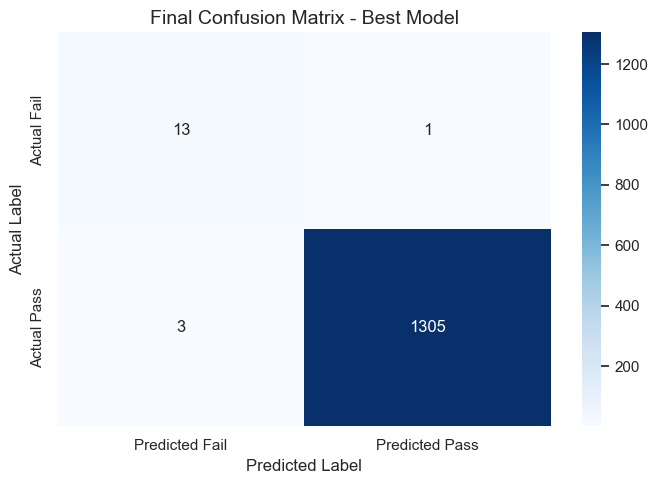

array([[  13,    1],
       [   3, 1305]])

In [20]:
# Cell 16 - Final Confusion Matrix

cm = confusion_matrix(y_test, y_pred_final, labels=[0, 1])

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Fail", "Predicted Pass"],
    yticklabels=["Actual Fail", "Actual Pass"]
)

plt.title("Final Confusion Matrix - Best Model", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_best_model.png", dpi=300, bbox_inches="tight")
plt.show()

cm

In [21]:
# Cell 17 - Confusion Matrix Interpretation

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix Interpretation")
print("-" * 60)

print(f"True Fail correctly predicted as Fail: {tn}")
print(f"Fail incorrectly predicted as Pass: {fp}")
print(f"Pass incorrectly predicted as Fail: {fn}")
print(f"True Pass correctly predicted as Pass: {tp}")

Confusion Matrix Interpretation
------------------------------------------------------------
True Fail correctly predicted as Fail: 13
Fail incorrectly predicted as Pass: 1
Pass incorrectly predicted as Fail: 3
True Pass correctly predicted as Pass: 1305


In [22]:
# Cell 18 - Save Final Results

final_results_path = TABLES_DIR / "final_model_results.csv"
prediction_comparison_path = TABLES_DIR / "final_prediction_method_comparison.csv"

final_results_df.to_csv(final_results_path, index=False)
prediction_comparison_df.to_csv(prediction_comparison_path, index=False)

print("Final results saved successfully:")
print("-", final_results_path)
print("-", prediction_comparison_path)

Final results saved successfully:
- ..\outputs\tables\final_model_results.csv
- ..\outputs\tables\final_prediction_method_comparison.csv


In [23]:
# Cell 19 - Threshold-Aware Permutation Importance

def threshold_macro_f1_scorer(estimator, X_eval, y_eval):
    pass_probability_eval = estimator.predict_proba(X_eval)[:, 1]
    y_pred_eval = np.where(pass_probability_eval >= best_threshold, 1, 0)
    return f1_score(y_eval, y_pred_eval, average="macro", zero_division=0)

print("Calculating threshold-aware permutation importance...")
print("This may take a moment.")

perm_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring=threshold_macro_f1_scorer,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance_Mean": perm_result.importances_mean,
    "Importance_STD": perm_result.importances_std
}).sort_values(by="Importance_Mean", ascending=False)

permutation_importance_df.head(15)

Calculating threshold-aware permutation importance...
This may take a moment.


,Feature,Importance_Mean,Importance_STD
0,Hours_Studied,0.339783,0.037340
1,Attendance,0.326767,0.032476
6,Previous_Scores,0.125475,0.035040
7,Motivation_Level,0.110591,0.027674
16,Parental_Education_Level,0.102684,0.033964
17,Distance_from_Home,0.102625,0.028866
2,Parental_Involvement,0.090349,0.029947
9,Tutoring_Sessions,0.086324,0.036488
3,Access_to_Resources,0.082969,0.031964
13,Peer_Influence,0.065943,0.012159


In [24]:
# Cell 20 - Save Permutation Importance

permutation_importance_path = TABLES_DIR / "permutation_importance.csv"

permutation_importance_df.to_csv(permutation_importance_path, index=False)

print("Permutation importance saved successfully.")
print("Saved to:", permutation_importance_path)

Permutation importance saved successfully.
Saved to: ..\outputs\tables\permutation_importance.csv


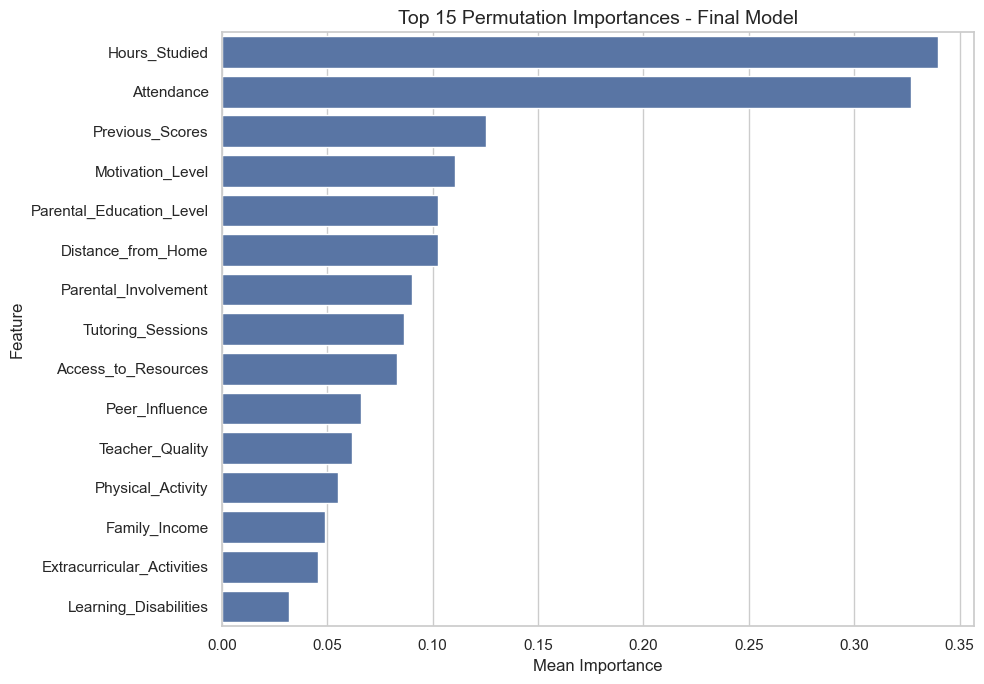

In [25]:
# Cell 21 - Plot Permutation Importance

top_perm_features = permutation_importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_perm_features,
    x="Importance_Mean",
    y="Feature"
)

plt.title("Top 15 Permutation Importances - Final Model", fontsize=14)
plt.xlabel("Mean Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "permutation_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
# Cell 22 - Extract Logistic Regression Coefficients

preprocessor = best_model.named_steps["preprocessor"]
model_step = best_model.named_steps["model"]

feature_names = []

num_features = preprocessor.transformers_[0][2]
feature_names.extend(num_features)

cat_transformer = preprocessor.named_transformers_["cat"]
cat_features = preprocessor.transformers_[1][2]

encoded_cat_features = cat_transformer.named_steps["encoder"].get_feature_names_out(cat_features)
feature_names.extend(encoded_cat_features)

coefficients = model_step.coef_[0]

logistic_coefficients_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
}).sort_values(by="Absolute_Coefficient", ascending=False)

logistic_coefficients_df.head(20)

,Feature,Coefficient,Absolute_Coefficient
1,Attendance,13.868543,13.868543
0,Hours_Studied,10.588135,10.588135
6,Parental_Involvement_High,7.650590,7.650590
9,Access_to_Resources_High,7.385644,7.385644
30,Learning_Disabilities_No,7.072532,7.072532
34,Parental_Education_Level_Postgraduate,6.766651,6.766651
19,Family_Income_High,6.322646,6.322646
37,Distance_from_Home_Near,6.025506,6.025506
18,Internet_Access_Yes,5.952488,5.952488
22,Teacher_Quality_High,5.902344,5.902344


In [27]:
# Cell 23 - Save Logistic Regression Coefficients

coefficients_path = TABLES_DIR / "logistic_regression_coefficients.csv"

logistic_coefficients_df.to_csv(coefficients_path, index=False)

print("Logistic regression coefficients saved successfully.")
print("Saved to:", coefficients_path)

Logistic regression coefficients saved successfully.
Saved to: ..\outputs\tables\logistic_regression_coefficients.csv


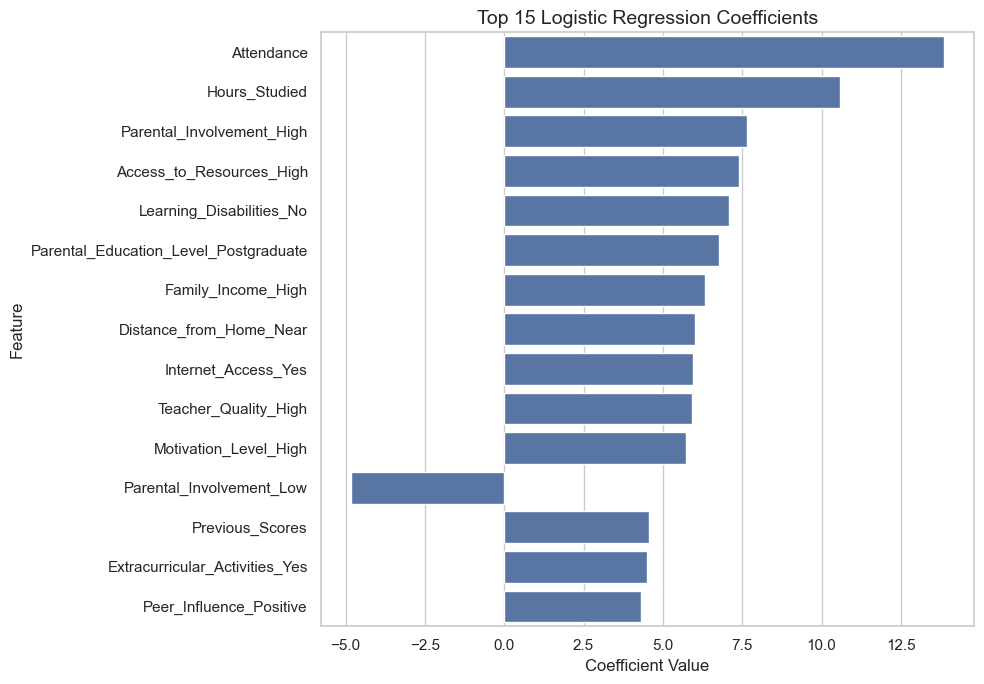

In [28]:
# Cell 24 - Plot Top Logistic Regression Coefficients

top_coef = logistic_coefficients_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_coef,
    x="Coefficient",
    y="Feature"
)

plt.title("Top 15 Logistic Regression Coefficients", fontsize=14)
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "logistic_regression_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
# Cell 25 - Save Compact Report-Ready Results

report_ready_results = pd.DataFrame({
    "Item": [
        "Final Model",
        "Prediction Method",
        "Accuracy",
        "Macro F1-score",
        "Balanced Accuracy",
        "Fail Recall",
        "Fail Precision",
        "Pass Recall",
        "Pass Precision",
        "True Fail Detected",
        "Fail Missed",
        "Pass Predicted as Fail",
        "True Pass Detected"
    ],
    "Value": [
        final_model_name,
        best_prediction_method,
        round(final_results["Accuracy"], 4),
        round(final_results["Macro_F1"], 4),
        round(final_results["Balanced_Accuracy"], 4),
        round(final_results["Fail_Recall"], 4),
        round(final_results["Fail_Precision"], 4),
        round(final_results["Pass_Recall"], 4),
        round(final_results["Pass_Precision"], 4),
        tn,
        fp,
        fn,
        tp
    ]
})

report_ready_results_path = TABLES_DIR / "report_ready_final_results.csv"
report_ready_results.to_csv(report_ready_results_path, index=False)

print("Report-ready final results saved successfully.")
print("Saved to:", report_ready_results_path)

report_ready_results

Report-ready final results saved successfully.
Saved to: ..\outputs\tables\report_ready_final_results.csv


,Item,Value
0,Final Model,LogisticRegression
1,Prediction Method,Threshold = 0.80
2,Accuracy,0.997
3,Macro F1-score,0.9326
4,Balanced Accuracy,0.9631
5,Fail Recall,0.9286
6,Fail Precision,0.8125
7,Pass Recall,0.9977
8,Pass Precision,0.9992
9,True Fail Detected,13


In [30]:
# Cell 26 - Final Model Summary Text

summary_text = f"""
Final Model Summary

Final Model:
{final_model_name}

Prediction Method:
{best_prediction_method}

Final Performance:
Accuracy: {final_results['Accuracy']:.4f}
Macro F1-score: {final_results['Macro_F1']:.4f}
Balanced Accuracy: {final_results['Balanced_Accuracy']:.4f}
Fail Recall: {final_results['Fail_Recall']:.4f}
Fail Precision: {final_results['Fail_Precision']:.4f}
Pass Recall: {final_results['Pass_Recall']:.4f}
Pass Precision: {final_results['Pass_Precision']:.4f}

Confusion Matrix:
True Fail correctly detected: {tn}
Fail incorrectly predicted as Pass: {fp}
Pass incorrectly predicted as Fail: {fn}
True Pass correctly detected: {tp}

Reason for Model Selection:
The final model was selected based on Macro F1-score, Balanced Accuracy, and Fail Recall rather than accuracy only because the dataset is highly imbalanced.

Explainability:
Threshold-aware permutation importance and Logistic Regression coefficients were used to explain which features influenced the model predictions.

Main Goal:
The main goal is to identify students at risk of failing so that early intervention can be provided.
"""

print(summary_text)


Final Model Summary

Final Model:
LogisticRegression

Prediction Method:
Threshold = 0.80

Final Performance:
Accuracy: 0.9970
Macro F1-score: 0.9326
Balanced Accuracy: 0.9631
Fail Recall: 0.9286
Fail Precision: 0.8125
Pass Recall: 0.9977
Pass Precision: 0.9992

Confusion Matrix:
True Fail correctly detected: 13
Fail incorrectly predicted as Pass: 1
Pass incorrectly predicted as Fail: 3
True Pass correctly detected: 1305

Reason for Model Selection:
The final model was selected based on Macro F1-score, Balanced Accuracy, and Fail Recall rather than accuracy only because the dataset is highly imbalanced.

Explainability:
Threshold-aware permutation importance and Logistic Regression coefficients were used to explain which features influenced the model predictions.

Main Goal:
The main goal is to identify students at risk of failing so that early intervention can be provided.



In [31]:
# Cell 27 - Save Final Model Summary

summary_path = TABLES_DIR / "final_model_summary.txt"

with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print("Final model summary saved successfully.")
print("Saved to:", summary_path)

Final model summary saved successfully.
Saved to: ..\outputs\tables\final_model_summary.txt


In [32]:
# Cell 28 - Save Final Model

final_model_path = MODELS_DIR / "best_student_performance_model.pkl"

joblib.dump(best_model, final_model_path)

print("Final model saved successfully.")
print("Saved to:", final_model_path)

Final model saved successfully.
Saved to: ..\outputs\models\best_student_performance_model.pkl


In [33]:
# Cell 29 - Save Final Threshold Info

final_threshold_info = {
    "prediction_method": best_prediction_method,
    "threshold": float(best_threshold),
    "rule": "If P(Pass) >= threshold, predict Pass; otherwise predict Fail."
}

final_threshold_path = MODELS_DIR / "final_threshold_info.pkl"

joblib.dump(final_threshold_info, final_threshold_path)

print("Final threshold information saved successfully.")
print("Saved to:", final_threshold_path)

Final threshold information saved successfully.
Saved to: ..\outputs\models\final_threshold_info.pkl


In [34]:
# Cell 30 - Final Output Check

print("05 Final Model Explainability Output Files")
print("-" * 60)

print("\nFigures:")
important_figures = [
    "confusion_matrix_best_model.png",
    "permutation_importance.png",
    "logistic_regression_coefficients.png"
]

for fig in important_figures:
    path = FIGURES_DIR / fig
    print(fig, "->", "Found" if path.exists() else "Not found")

print("\nTables:")
important_tables = [
    "final_model_results.csv",
    "final_prediction_method_comparison.csv",
    "permutation_importance.csv",
    "logistic_regression_coefficients.csv",
    "report_ready_final_results.csv",
    "final_model_summary.txt"
]

for table in important_tables:
    path = TABLES_DIR / table
    print(table, "->", "Found" if path.exists() else "Not found")

print("\nModels:")
important_models = [
    "best_student_performance_model.pkl",
    "final_threshold_info.pkl"
]

for model in important_models:
    path = MODELS_DIR / model
    print(model, "->", "Found" if path.exists() else "Not found")

05 Final Model Explainability Output Files
------------------------------------------------------------

Figures:
confusion_matrix_best_model.png -> Found
permutation_importance.png -> Found
logistic_regression_coefficients.png -> Found

Tables:
final_model_results.csv -> Found
final_prediction_method_comparison.csv -> Found
permutation_importance.csv -> Found
logistic_regression_coefficients.csv -> Found
report_ready_final_results.csv -> Found
final_model_summary.txt -> Found

Models:
best_student_performance_model.pkl -> Found
final_threshold_info.pkl -> Found


In [35]:
# Cell 31 - Markdown
"""
## Final Model Explainability Summary

This notebook completed the final model evaluation and explainability stage.

The final selected model is Logistic Regression with threshold tuning.

The model was evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- Macro F1-score
- Balanced Accuracy
- Fail Recall
- Confusion Matrix

Because the dataset is highly imbalanced, the final model was not selected based on accuracy alone.

Threshold-aware permutation importance and logistic regression coefficients were used to explain which features influenced the predictions.

The final model, threshold information, results tables, and report figures were saved for use in the final report, presentation, and prediction demo.
"""

'\n## Final Model Explainability Summary\n\nThis notebook completed the final model evaluation and explainability stage.\n\nThe final selected model is Logistic Regression with threshold tuning.\n\nThe model was evaluated using:\n- Accuracy\n- Precision\n- Recall\n- F1-score\n- Macro F1-score\n- Balanced Accuracy\n- Fail Recall\n- Confusion Matrix\n\nBecause the dataset is highly imbalanced, the final model was not selected based on accuracy alone.\n\nThreshold-aware permutation importance and logistic regression coefficients were used to explain which features influenced the predictions.\n\nThe final model, threshold information, results tables, and report figures were saved for use in the final report, presentation, and prediction demo.\n'